# Random Forest Classifier

## Objective

The objective of this experiment is to train a Random Forest classifier using the Titanic dataset.

The model performance will be evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Finally, the results will be compared with Logistic Regression and Decision Tree models.

## 1. Importing Libraries

In this section, the required Python libraries are imported for data preprocessing, model training, and evaluation.

In [6]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score, recall_score,f1_score)

from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

## 2. Loading the Dataset

The Titanic dataset is loaded for training and evaluating the Random Forest classifier.

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Initial Data Analysis

The dataset is inspected to verify its structure, data types, and statistical properties before preprocessing.

In [8]:
# Check dataset information
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 4. Data Cleaning

The dataset is cleaned by removing unnecessary columns and handling missing values to improve data quality

In [9]:
df = pd.read_csv("Titanic-Dataset.csv")

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Fare'] = df['Fare'].fillna(df['Fare'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### Encoding Categorical Variables

Categorical features are converted into numerical values using one-hot encoding because machine learning algorithms require numerical input.

In [10]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## 5. Preparing Data for Training

The dataset is divided into features (X) and the target variable (y).

The target variable is "Survived", while all remaining columns are used as input features.

In [11]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

## 6. Splitting the Dataset

The dataset is divided into training and testing subsets using the same parameters as in previous experiments.

This ensures a fair comparison between all models.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Training the Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Instead of relying on a single tree, the algorithm aggregates predictions from many trees to improve accuracy and reduce overfitting.

In [13]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

## 8. Training the Random Forest Model

The Random Forest model is trained using the training dataset.

During this process, the algorithm builds multiple decision trees and learns patterns between the input features and the target variable.

In [14]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 9. Making Predictions

After training the Random Forest model, predictions are generated for the testing dataset.

These predictions are used to evaluate the performance of the classifier.

In [18]:
y_pred_rf = random_forest.predict(X_test)

## 10. Model Evaluation

The performance of the Random Forest classifier is evaluated using four metrics:

- Accuracy
- Precision
- Recall
- F1-score

These metrics provide a comprehensive assessment of the model's predictive performance.

In [19]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1-score:", round(rf_f1, 3))

Accuracy: 0.827
Precision: 0.877
Recall: 0.676
F1-score: 0.763


## 11. Confusion Matrix

The confusion matrix illustrates the classification performance of the Random Forest classifier.

It shows the number of correct and incorrect predictions for each class and provides additional insight into the model's strengths and weaknesses.

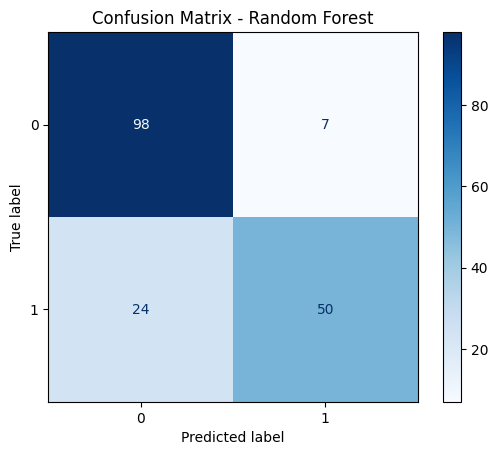

In [35]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")

plt.show()

## 12. Model Comparison

The performance of the three machine learning models is compared using Accuracy, Precision, Recall, and F1-score.

In [39]:
comparison = pd.DataFrame({"Model": ["Logistic Regression", "Decision Tree", "Random Forest"],"Accuracy":[0.816,0.821,0.827],"Precision": [0.797,0.839,0.877],"Recall": [0.743, 0.703, 0.676], "F1-score": [0.769, 0.765, 0.763]})
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.816,0.797,0.743,0.769
1,Decision Tree,0.821,0.839,0.703,0.765
2,Random Forest,0.827,0.877,0.676,0.763


## Confusion Matrix Analysis

The confusion matrices provide additional insight into the prediction performance of the evaluated machine learning models.

The table below summarizes the number of correct and incorrect predictions made by each classifier.

In [40]:
cma = pd.DataFrame({"Model": ["Logistic Regression", "Decision Tree", "Random Forest"],"True Negative":[91,95,98],"False Positive": [14,10,7],"False Negative": [19, 22, 24], "True Positive": [55,52, 50]})
cma

,Model,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,91,14,19,55
1,Decision Tree,95,10,22,52
2,Random Forest,98,7,24,50


## Analysis of Results

The comparison of the three machine learning models shows that each algorithm has its own strengths.

Random Forest achieved the highest Accuracy (0.827) and Precision (0.877), indicating the best overall classification performance and the lowest number of false positive predictions.

Logistic Regression achieved the highest Recall (0.743) and F1-score (0.769), providing the most balanced performance in identifying positive cases.

Decision Tree produced competitive results, but it did not outperform the other models across all evaluation metrics.

The confusion matrix analysis confirms these findings. Random Forest correctly classified the highest number of negative cases (98) and produced the fewest false positive predictions (7), while Logistic Regression correctly identified the largest number of positive cases (55).

These results demonstrate that different machine learning algorithms should be evaluated using multiple performance metrics rather than Accuracy alone.

## Conclusion

In this experiment, the Random Forest classifier was trained and compared with Logistic Regression and Decision Tree using the Titanic dataset.

Random Forest achieved the highest Accuracy and Precision, while Logistic Regression achieved the highest Recall and F1-score.

Overall, the results show that different machine learning models have different strengths, and the choice of the best model depends on the evaluation metric and the objectives of the classification task.